# Elemento `Truss`

El elemento `Truss` plano es un elemento finito con coordenadas locales y globales, tiene un modulo de elasticidad $E$, una sección transversal $A$ y una longitud $L$. Cada elemento tiene dos nodos y un ángulo de inclinación $\theta$ medido en sentido antihorario desde el eje $X$ global, como se muestra en la figura. Sean $C=\cos(\theta)$ y $S=\sin(\theta)$, entonces la matriz de rigidez por elemento está dada por:

$$
k = \frac{EA}{L}
\begin{bmatrix}
C^2 & CS & -C^2 & -CS \\
CS & S^2 & -CS & -S^2 \\
-C^2 & -CS & C^2 & CS \\
-CS & -S^2 & CS & S^2 \\
\end{bmatrix}
$$

<img src="src/truss-element/truss_element.PNG" width="200px">

El elemento `Truss` tiene dos grados de libertad en cada nodo: desplazamientos en `X` e `Y`. 

La fuerza en cada elemento se calcula como sigue:

$$
f = \frac{EA}{L} \begin{bmatrix} -C & -S & C & S \end{bmatrix} \left\{ u \right\}
$$

Donde $f$ es la fuerza (escalar) en el elemento y $\left\{u\right\}$ el vector de desplazamientos en el elemento. Una fuerza negativa indica que el elemento está sometido a compresión.

El esfuerzo en el elemento se obtiene dividiendo la fuerza $f$ por la sección transversal, es decir:

$$
\sigma = \frac{f}{A}
$$

## Ejemplo 1. Estructura simple de tres elementos

Como primer ejemplo vamos a resolver una estructura simple de tres elementos, con un apoyo fijo en A, un soporte simple en C y una fuerza horizontal de 500 N en B, como se muestra en la figura.

<figure>
<img src="src/truss-element/example_01.png" width="250px">
<center><figcaption>Fuente: [1]</figcaption></center>
</figure>

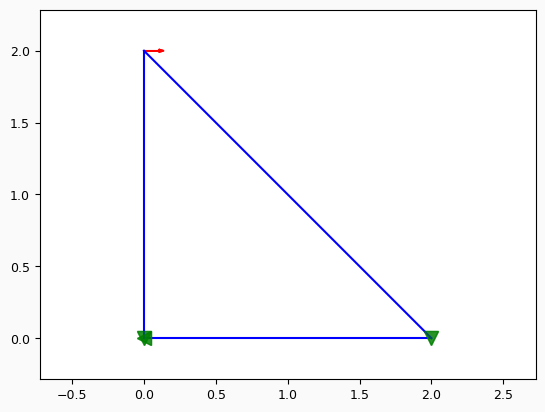

In [4]:
from nusa import * # Importando nusa

E,A = 210e9, 3.1416*(10e-3)**2
n1 = Node((0,0))
n2 = Node((2,0))
n3 = Node((0,2))
e1 = Truss((n1,n2),E,A)
e2 = Truss((n1,n3),E,A)
e3 = Truss((n2,n3),E,A)
m = TrussModel()
for n in (n1,n2,n3): m.add_node(n)
for e in (e1,e2,e3): m.add_element(e)
m.add_constraint(n1, ux=0, uy=0)
m.add_constraint(n2, uy=0)
m.add_force(n3, (500,0))
m.plot_model()
m.solve()

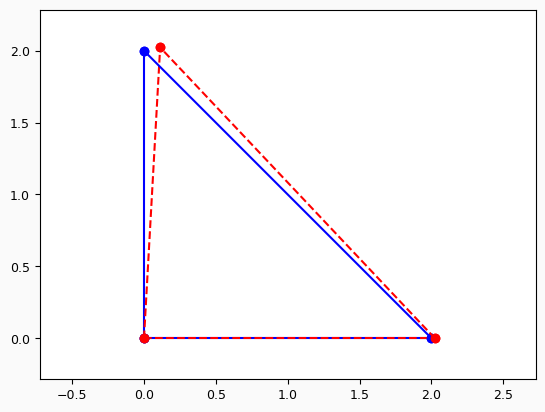

In [5]:
m.plot_deformed_shape()

---

## Ejemplo 2.


<img src="src/truss-element/example_02.png" width="300px">

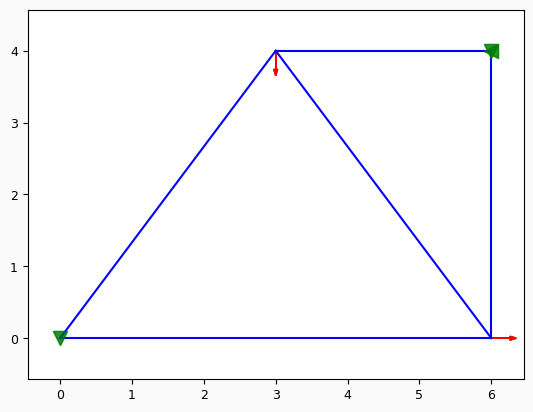

In [7]:
E,A = 200e9, 0.01
n1 = Node((0,0))
n2 = Node((6,0))
n3 = Node((6,4))
n4 = Node((3,4))
e1 = Truss((n1,n2),E,A)
e2 = Truss((n2,n3),E,A)
e3 = Truss((n4,n3),E,A)
e4 = Truss((n1,n4),E,A)
e5 = Truss((n2,n4),E,A)
m = TrussModel()
for n in (n1,n2,n3,n4): m.add_node(n)
for e in (e1,e2,e3,e4,e5): m.add_element(e)
m.add_constraint(n1, uy=0)
m.add_constraint(n3, ux=0, uy=0)
m.add_force(n2, (600,0))
m.add_force(n4, (0,-400))
m.plot_model()
m.solve()

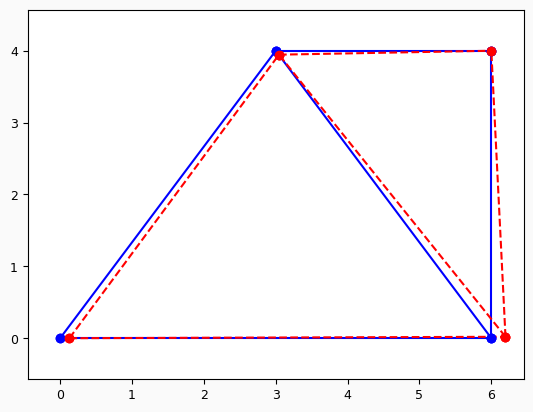

In [8]:
m.plot_deformed_shape()

In [9]:
m.simple_report()

AttributeError: 'TrussModel' object has no attribute 'self'

## Ejemplo 3

<figure>
<img src="src/truss-element/example_03.png" width="350px">
<center><figcaption>Fuente: [2]</figcaption></center>
</figure>

In [ ]:
E,A = 29e6, 0.1
n1 = Node((0,0)) # A
n2 = Node((8*12,6*12)) # B
n3 = Node((8*12,0)) # C
n4 = Node((16*12,8*12+4)) # D
n5 = Node((16*12,0)) # E
n6 = Node((24*12,6*12)) # F
n7 = Node((24*12,0)) # G
n8 = Node((32*12,0)) # H

e1 = Truss((n1,n2),E,A)
e2 = Truss((n1,n3),E,A)
e3 = Truss((n2,n3),E,A)
e4 = Truss((n2,n4),E,A)
e5 = Truss((n2,n5),E,A)
e6 = Truss((n3,n5),E,A)
e7 = Truss((n5,n4),E,A)
e8 = Truss((n4,n6),E,A)
e9 = Truss((n5,n6),E,A)
e10 = Truss((n5,n7),E,A)
e11 = Truss((n6,n7),E,A)
e12 = Truss((n6,n8),E,A)
e13 = Truss((n7,n8),E,A)

m = TrussModel("Gambrel Roof")
for n in (n1,n2,n3,n4,n5,n6,n7,n8): m.add_node(n)
for e in (e1,e2,e3,e4,e5,e6,e7,e8,e9,e10,e11,e12,e13): m.add_element(e)

m.add_constraint(n1, uy=0)
m.add_constraint(n8, ux=0, uy=0)
m.add_force(n2, (0,-600))
m.add_force(n4, (0,-600))
m.add_force(n6, (0,-600))
m.add_force(n8, (0,-300))
m.add_force(n1, (0,-300))
m.plot_model()
m.solve()

In [ ]:
m.plot_deformed_shape()

In [ ]:
m.simple_report()

## Referencias

* [1] Hibbeler, R.C. (2010). *Engineering Mechanics, Statics*. Pearson
* [2] Beer, F.P. et. al. (2013) *Vector Mechanics for Engineers, Statics and Dynamics*. McGraw-Hill